This junction is modeled as a one-dimensional silicon p-n homojunction at thermal equilibrium. 

The p side is to the left of the junction and the n side is to the right.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
q = 1.602e-19 #charge (C)
PERMITTIVITY = 8.854e-12
k = 1.381e-23 #boltzmann constant (F/m)
T = 300       #Temperature (K)
epsilon = 11.7*PERMITTIVITY #silicon permittivity

In [3]:
L = 1e-4    #device length (m)
N = 10000   #number of grid points

x = np.linspace(0,L,N)
dx = x[1] - x[0]

In [4]:
junction_position = L/2 #the junction is placed at the center of the device

In [5]:
N_A = 1e16 * 1e6 #acceptor concentration (converted to m^-3)
N_D = 1e16 * 1e6 #donor concentration (converted to m^-3)

n_i = 1e10 * 1e6 #intrinsic carrier concentration of Si (converted to m^-3)

In equilibrium, the built in potential is given by
$$V_b = \frac{kT}{q}ln(\frac{{N_A}{N_D}}{n_i^2})$$

In [6]:
V_b = (k*T)/q * np.log((N_A*N_D)/n_i**2)
print("Built in potential =", V_b, "V")

Built in potential = 0.7145775311066914 V


Under the depletion approximation, the depletion widths on the n and p sides are
$$x_n = \sqrt{\frac{2{\epsilon}{V_b}}{q}\frac{N_A}{N_D(N_A + N_D)}}$$
and
$$x_p = \sqrt{\frac{2{\epsilon}{V_b}}{q}\frac{N_D}{N_A(N_A + N_D)}}$$

In [7]:
x_n = np.sqrt(2*epsilon*V_b/q * N_A/(N_D*(N_A+N_D)))
print(x_n)
x_p = np.sqrt(2*epsilon*V_b/q * N_D/(N_A*(N_A+N_D)))
print(x_p)

2.1495923703653023e-07
2.1495923703653023e-07


In [8]:
rho = np.zeros(N) #numpy array of charge densities

p_boundary = junction_position - x_p #position of boundary of depletion region on p side
n_boundary = junction_position + x_n #position of boundary of depletion region on n side

Within the depletion region, the number of mobile carriers is assumed to be negligible.

The charge density is therefore determined by the fixed ionized dopants.
$$
\rho(x) =
\begin{cases}
-qN_A & \text{on the p-side}\\
+qN_D & \text{on the n-side}\\
0 & \text{outside the depletion region}
\end{cases}
$$

In [9]:
for i in range(N):
    if p_boundary <= x[i] < junction_position:
        rho[i] = -q * N_A
    elif junction_position <= x[i] <= n_boundary:
        rho[i] = q * N_D
    else:
        rho[i] = 0.0

The array of charge densities is used in Poisson's equation:
$$\frac{d^2V}{dx^2} = -\frac{\rho(x)}{\epsilon}$$
The second derivative is discretized using the central finite-difference approximation, producing a linear system of equations
$$AV = b$$

In [10]:
A = np.zeros((N,N))
for i in range(1, N-1):
    A[i,i-1] = 1
    A[i,i] = -2
    A[i, i+1] = 1
A = A/(dx**2)

The potential difference between the 2 sides of the junction is set to the equilibrium built-in potential:
$$V(0) = 0,      V(L) = V_b$$

In [11]:
b = -rho/epsilon

#boundary conditions
A[0,:] = 0
A[0,0] = 1
A[-1,:] = 0
A[-1,-1] = 1
b[0] = 0
b[-1] = V_b

In [12]:
V = np.linalg.solve(A,b)

The electric field is obtained from the electrostatic potential:
$$E(x) = -\frac{dV}{dx}$$

In [13]:
E = -np.gradient(V,dx)

In [14]:
print("dx =", dx * 1e6, "um")
print("x_p =", x_p * 1e6, "um")
print("x_n =", x_n * 1e6, "um")
print("depletion width =", (x_p + x_n) * 1e6, "um")
print("min charge density =", np.min(rho))
print("max charge density =", np.max(rho))

dx = 0.010001000100010001 um
x_p = 0.21495923703653022 um
x_n = 0.21495923703653022 um
depletion width = 0.42991847407306044 um
min charge density = -1602.0
max charge density = 1602.0


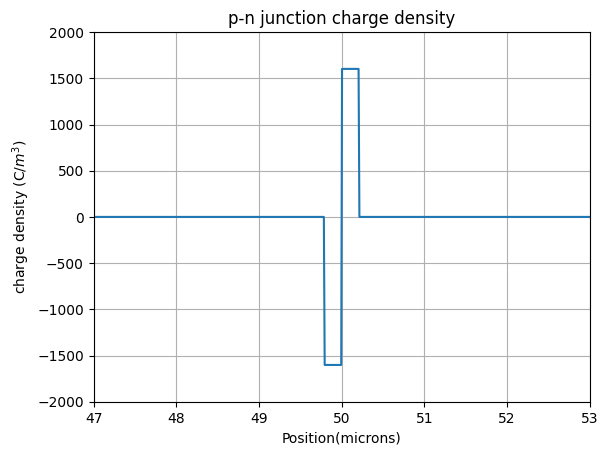

In [15]:
plt.figure()
plt.plot(x*1e6, rho)
plt.xlabel("Position(microns)")
plt.ylabel("charge density (C/$m^3$)")
plt.title("p-n junction charge density")
plt.ylim(-2000,2000)
plt.xlim(47,53)
plt.grid()
plt.show()

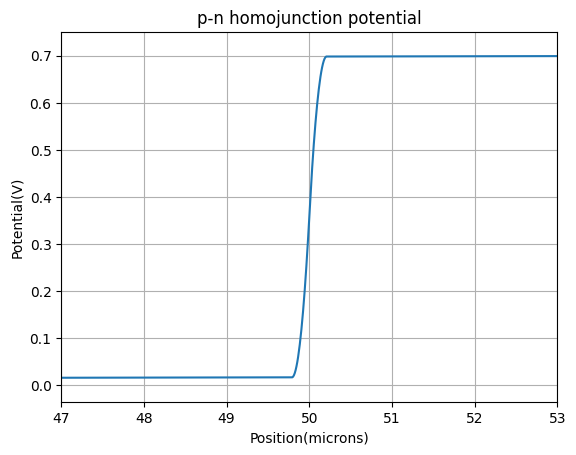

In [16]:
plt.figure()
plt.plot(x*1e6, V)
plt.xlabel("Position(microns)")
plt.ylabel("Potential(V)")
plt.title("p-n homojunction potential")
plt.xlim(47,53)
plt.grid()
plt.show()

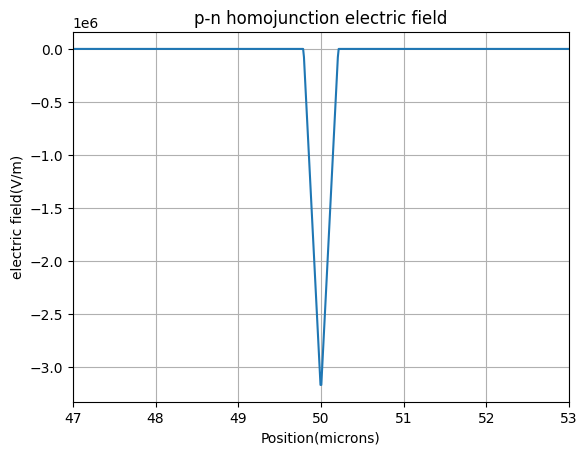

In [17]:
plt.figure()
plt.plot(x*1e6, E)
plt.xlabel("Position(microns)")
plt.ylabel("electric field(V/m)")
plt.title("p-n homojunction electric field")
plt.xlim(47,53)
plt.grid()
plt.show()